In [ ]:
#make natural jenks, quantiles and equal interval classifications for output raster which i will have to input each time and let me change the parameters of how many jenks, quantiles and intervals. create visualizations for each one
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count()))  # silence joblib/loky wmic warning on Windows

import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify as mc

def classify_raster(raster_path, n_jenks=5, n_quantiles=6, n_equal=5, nodata=None):
    """Classify a raster with Natural Breaks (Jenks), Quantiles and Equal Interval schemes.

    Returns a dict with the source data, mask and one entry per scheme containing
    the classified array, breakpoints (bin edges) and the mapclassify classifier object.
    """
    with rasterio.open(raster_path) as src:
        data = src.read(1).astype(float)
        profile = src.profile
        nodata = src.nodata if nodata is None else nodata

    mask = np.isfinite(data)
    if nodata is not None:
        mask &= data != nodata
    values = data[mask]

    schemes = {
        "natural_breaks": mc.NaturalBreaks(values, k=n_jenks),
        "quantiles": mc.Quantiles(values, k=n_quantiles),
        "equal_interval": mc.EqualInterval(values, k=n_equal),
    }

    results = {"data": data, "mask": mask, "profile": profile, "raster_path": raster_path}
    for name, classifier in schemes.items():
        classified = np.full(data.shape, np.nan)
        classified[mask] = classifier.yb
        results[name] = {
            "classifier": classifier,
            "bins": classifier.bins,
            "classified": classified,
        }
    return results

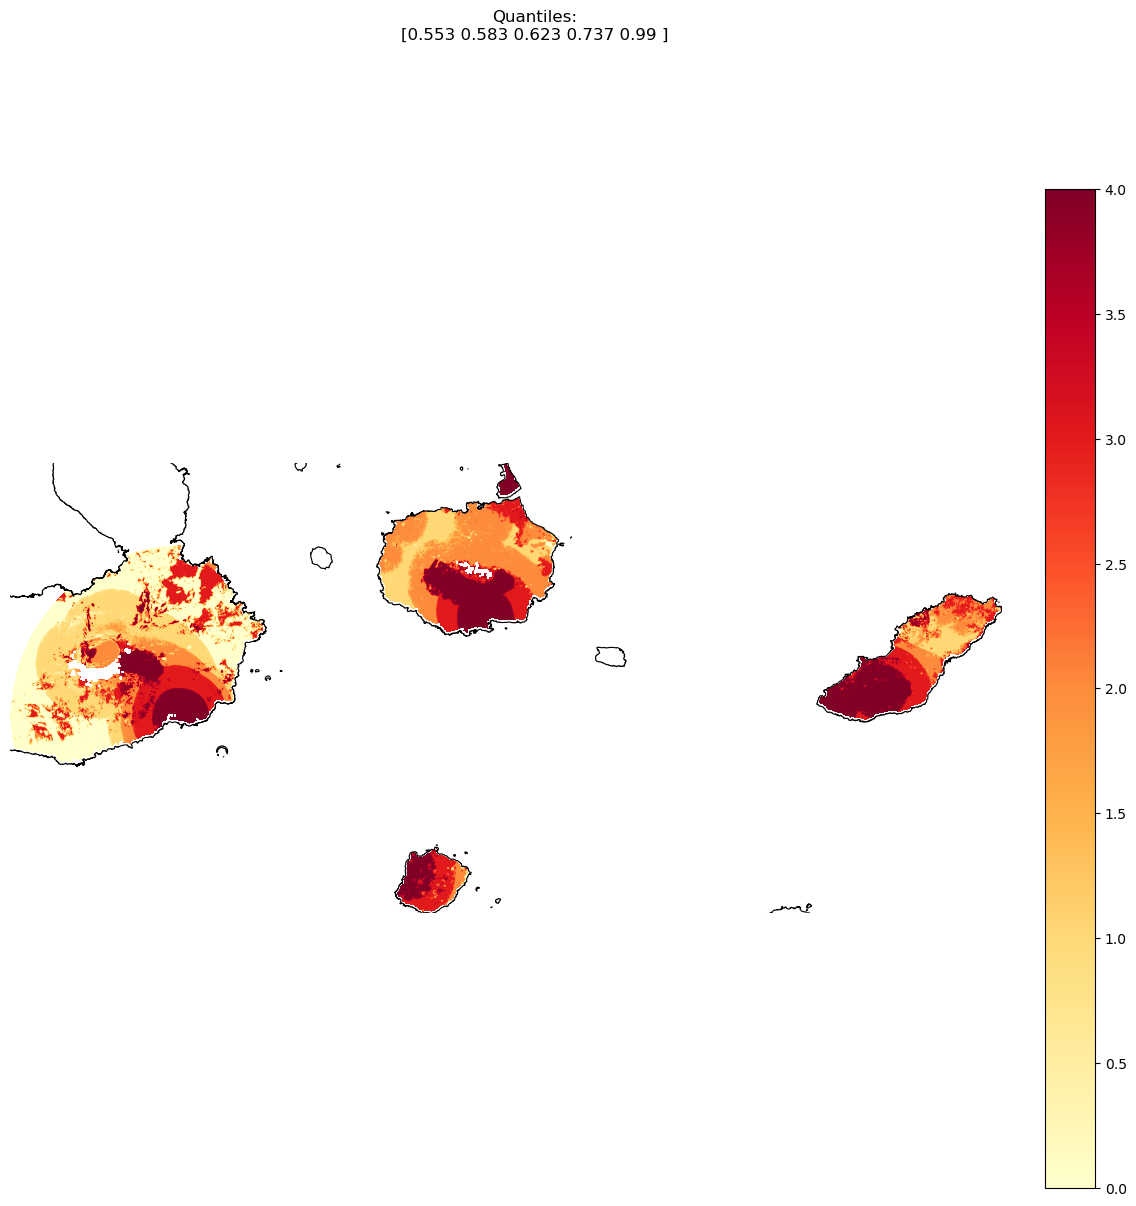

In [42]:
#C:\HyGalapagos\outputs_solar\scenario_2\candidate_raster_20260923_094417.tif
raster_path = r"C:\HyGalapagos\outputs_solar\scenario_2\weighted_suitability_20260923_094417.tif"
n_quantiles = 5
galapagos_boundary = r"C:\Galapagos_IERSE\01_Organizacion_Territorial\Provincia_Galapagos_CONALI_2018.shp"

results = classify_raster(raster_path, n_quantiles=n_quantiles)

# crop to the bounding box of valid data so the islands fill the figure
rows, cols = np.where(results["mask"])
r0, r1, c0, c1 = rows.min(), rows.max() + 1, cols.min(), cols.max() + 1
cropped = results["quantiles"]["classified"][r0:r1, c0:c1]

# geographic extent of the cropped window, to align the island outlines with the raster
transform = results["profile"]["transform"]
x0, y0 = transform * (c0, r0)
x1, y1 = transform * (c1, r1)
extent = [x0, x1, y1, y0]

islands = gpd.read_file(galapagos_boundary).to_crs(results["profile"]["crs"])

fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(cropped, cmap="YlOrRd", extent=extent, origin="upper")
islands.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
fig.suptitle(f"Quantiles:\n{np.round(results['quantiles']['bins'], 3)}", y=0.98)
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

Plotting 5 quantile classes (re-run the previous cell after changing n_quantiles)


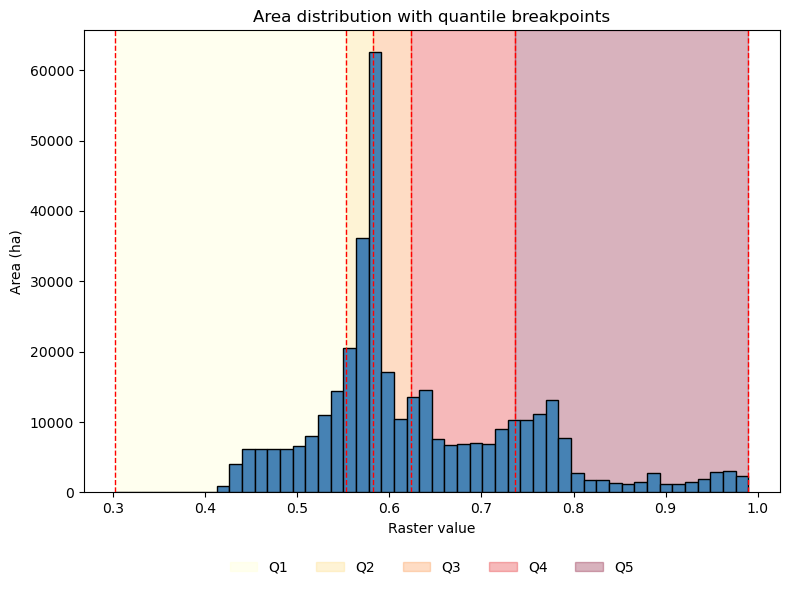

In [ ]:
# histogram of raster values (area in km2) with quantile breakpoints marked and shaded classes
values = results["data"][results["mask"]]
bins = results["quantiles"]["bins"]
edges = np.concatenate(([values.min()], bins))
cmap = plt.get_cmap("YlOrRd", len(bins))

transform = results["profile"]["transform"]
pixel_area_ha = abs(transform.a * transform.e) / 1e4
weights = np.full(values.shape, pixel_area_ha)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(values, bins=50, weights=weights, edgecolor="black", color="steelblue", zorder=3)
for b in edges:
    ax.axvline(b, color="red", linestyle="--", linewidth=1, zorder=4)

legend_handles = []
for i in range(len(edges) - 1):
    ax.axvspan(edges[i], edges[i + 1], color=cmap(i), alpha=0.3, zorder=1)
    legend_handles.append(plt.Rectangle((0, 0), 1, 1, color=cmap(i), alpha=0.3))

ax.set_xlabel("Raster value")
ax.set_ylabel("Area (ha)")
ax.set_title("Area distribution with quantile breakpoints")
legend_ncol = min(len(edges) - 1, 6)
ax.legend(
    legend_handles,
    [f"Q{i + 1}" for i in range(len(edges) - 1)],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=legend_ncol,
    frameon=False,
)
plt.tight_layout()
plt.show()

In [38]:
# extract the last quantile class and save it as a raster, keeping the suitability values
out_dir = r"C:\HyGalapagos\outputs_solar\postprocessing_quantiles"
os.makedirs(out_dir, exist_ok=True)

last_class = results["quantiles"]["classifier"].k - 1
last_quantile_values = np.where(
    results["quantiles"]["classified"] == last_class, results["data"], np.nan
).astype("float32")

out_profile = results["profile"].copy()
out_profile.update(dtype="float32", count=1, nodata=np.nan)

base_name = os.path.splitext(os.path.basename(results["raster_path"]))[0]
out_path = os.path.join(out_dir, f"{base_name}_Q5.tif")

with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(last_quantile_values, 1)

print(f"Saved: {out_path}")

Saved: C:\HyGalapagos\outputs_solar\postprocessing_quantiles\weighted_suitability_20260923_094417_Q5.tif


In [39]:
# area of the last quantile class per island, saved as csv
import geopandas as gpd
import pandas as pd
from pathlib import Path
from rasterio.mask import mask as rio_mask

BASE_ROOT = Path(r"C:/Galapagos_IERSE/01_Organizacion_Territorial")
ISLAND_FILES = {
    "Isabela": BASE_ROOT / "solo_isabela.shp",
    "Floreana": BASE_ROOT / "floreana.shp",
    "Santa Cruz": BASE_ROOT / "santa_cruz_baltra.shp",
    "San Cristobal": BASE_ROOT / "san_cristobal.shp",
}
SOLAR_HA_PER_MW = 1.3

with rasterio.open(out_path) as src:
    raster_crs = src.crs
    island_areas = []
    for island, shp_path in ISLAND_FILES.items():
        gdf = gpd.read_file(shp_path).to_crs(raster_crs)
        clipped, _ = rio_mask(src, gdf.geometry, crop=True, nodata=np.nan)
        area_ha = np.isfinite(clipped[0]).sum() * pixel_area_ha
        island_areas.append({
            "island": island,
            "area_ha_last_quantile": area_ha,
            "energy_potential_mw": area_ha / SOLAR_HA_PER_MW,
        })


island_areas_df = pd.DataFrame(island_areas)

csv_path = os.path.join(out_dir, f"{base_name}_last_quantile_area_by_island.csv")
island_areas_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")
island_areas_df

Saved: C:\HyGalapagos\outputs_solar\postprocessing_quantiles\weighted_suitability_20260923_094417_last_quantile_area_by_island.csv


,island,area_ha_last_quantile,energy_potential_mw
0,Isabela,22379.556830,17215.043715
1,Floreana,6921.325105,5324.096235
2,Santa Cruz,23563.917064,18126.090049
3,San Cristobal,20923.602341,16095.078724
